# One-Dimensional Burgers' Equation

This code simulates the one-dimensional Burgers' equation:

$$\frac{\partial u}{\partial t}+u\frac{\partial u}{\partial x}=\nu\frac{\partial^2 u}{\partial x^2}$$
$$t\in(0,1)\quad x\in(-1,1)$$
$$u(x,0)=-\sin(\pi x)$$
$$u(-1,t)=0\quad u(1,t)=0$$

I take two approaches: finite differences and a PINN method.

# Part 1: Finite Differences

In [2]:
# imports

import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import copy
from scipy.stats import gamma, lognorm, pearsonr

In [6]:
# classical method (finite differences with upwind scheme)

# parameters
nx = 200  # number of x points
nt = 1000 # number of t points
L = 2     # length of x-domain
T = 1     # length of t-domain
nu = 0.01 # viscosity

dx = L/(nx-1)
dt = T/nt

x = np.linspace(-0.5*L, 0.5*L, nx)

u = np.zeros((nx,nt+1))
u[:,0] = -np.sin(np.pi*x) # initial condition

start_time = time.time()

for i in range(nt):
  ui = u[:,i].copy()

  for j in range(1,nx-1):
    # upwind scheme
    if(ui[j]>0):
      ux = (ui[j] - ui[j-1]) / dx
    else:
      ux = (ui[j+1] - ui[j]) / dx

    uxx = (ui[j+1] - 2*ui[j] + ui[j-1]) / dx**2

    u[j,i+1] = ui[j] - dt*ui[j]*ux + nu*dt*uxx

  u[0,i+1] = 0
  u[-1,i+1] = 0

elapsed_time_classical = time.time() - start_time
print(f"Elapsed time: {elapsed_time_classical:>5.2f}s")

Elapsed time:  0.48s


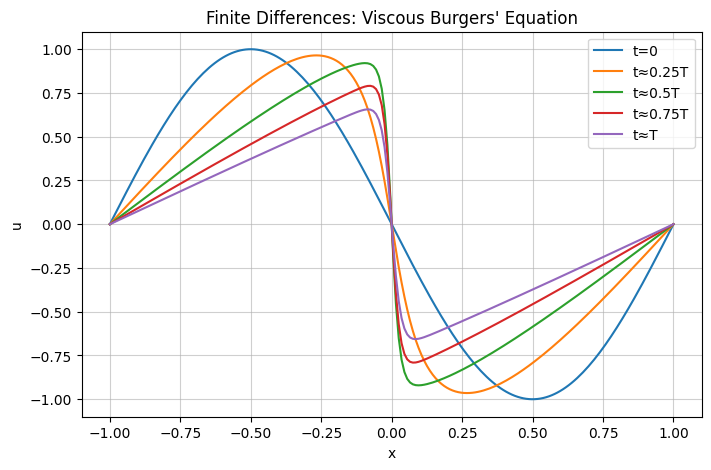

In [7]:
# plotting the classical results

plt.figure(figsize=(8, 5))
plt.plot(x, u[:,0], label="t=0")
plt.plot(x, u[:,250], label="t≈0.25T")
plt.plot(x, u[:,500], label="t≈0.5T")
plt.plot(x, u[:,750], label="t≈0.75T")
plt.plot(x, u[:,-1], label="t≈T")
plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True, alpha=0.6)
plt.title("Finite Differences: Viscous Burgers' Equation")
plt.show()

# Part 2: Single PINN Training

In [ ]:
# setting up the PINN

class PDE_Net(nn.Module):
    def __init__(self):
        super(PDE_Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 35),
            nn.Tanh(),
            nn.Linear(35, 35),
            nn.Tanh(),
            nn.Linear(35, 35),
            nn.Tanh(),
            nn.Linear(35, 35),
            nn.Tanh(),
            nn.Linear(35, 1)
        )

    def forward(self, x):
        return self.net(x)

def compute_burgers_residual(model, s, nu):

    s.requires_grad_(True)
    u = model(s)

    # computing first derivatives
    grad_u_s = torch.autograd.grad(
        outputs=u,
        inputs=s,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    # extract u_x and u_t
    u_x = grad_u_s[:, 0:1]
    u_t = grad_u_s[:, 1:2]

    # compute second spatial derivative: d^2u/dx^2
    grad_ux_s = torch.autograd.grad(
        outputs=u_x,
        inputs=s,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_xx = grad_ux_s[:, 0:1]

    # compute residual
    residual = u_t + u * u_x - nu * u_xx

    return residual

Epoch 0 | Runtime:  0.03s | Total Loss: 0.513490 | PDE: 0.000954 | IC: 0.512255 | BC: 0.000280
Epoch 500 | Runtime: 11.88s | Total Loss: 0.093008 | PDE: 0.038440 | IC: 0.051348 | BC: 0.003219
Epoch 1000 | Runtime: 23.68s | Total Loss: 0.025479 | PDE: 0.013010 | IC: 0.010938 | BC: 0.001531
Epoch 1500 | Runtime: 35.42s | Total Loss: 0.017187 | PDE: 0.008903 | IC: 0.007416 | BC: 0.000868
Epoch 2000 | Runtime: 47.30s | Total Loss: 0.011087 | PDE: 0.006351 | IC: 0.004113 | BC: 0.000622
Epoch 2500 | Runtime: 59.00s | Total Loss: 0.009562 | PDE: 0.006759 | IC: 0.002344 | BC: 0.000459
Epoch 3000 | Runtime: 70.85s | Total Loss: 0.005125 | PDE: 0.003350 | IC: 0.001387 | BC: 0.000387
Epoch 3500 | Runtime: 82.07s | Total Loss: 0.003656 | PDE: 0.002644 | IC: 0.000881 | BC: 0.000130
Epoch 4000 | Runtime: 93.51s | Total Loss: 0.002660 | PDE: 0.001885 | IC: 0.000666 | BC: 0.000109
Epoch 4500 | Runtime: 105.37s | Total Loss: 0.002036 | PDE: 0.001464 | IC: 0.000463 | BC: 0.000109
Epoch 5000 | Runtime: 1

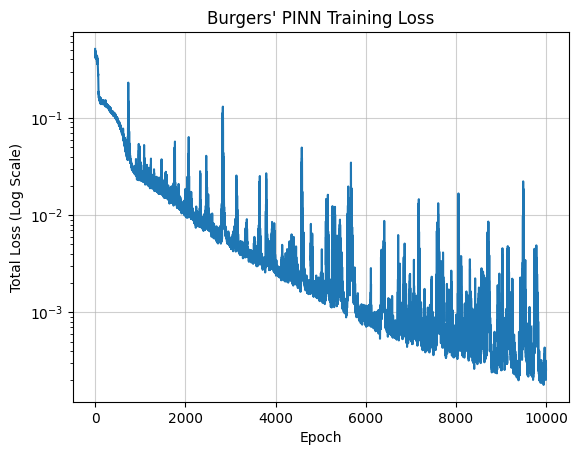

In [ ]:
# PINN training

pinn_model = PDE_Net()
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.0015)
epochs = 10000

# domain parameters
x_min, x_max = -0.5*L, 0.5*L
t_min, t_max = 0, T

loss_history = []

start_time = time.time()

for epoch in range(epochs):
    optimizer.zero_grad()

    # generate 2000 random (x, t) points inside the domain
    x_domain = L * torch.rand((2000, 1)) + x_min
    t_domain = T * torch.rand((2000, 1)) + t_min
    s_domain = torch.cat([x_domain, t_domain], dim=1)

    # compute PDE residual using the function from earlier
    residual = compute_burgers_residual(pinn_model, s_domain, nu)
    loss_pde = torch.mean(residual**2)

    # generate 500 random x points at time t = 0
    x_ic = L * torch.rand((500, 1)) + x_min
    t_ic = torch.zeros((500, 1))
    s_ic = torch.cat([x_ic, t_ic], dim=1)

    # compute IC loss
    u_ic_pred = pinn_model(s_ic)
    u_ic_target = -torch.sin(torch.pi * x_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic_target)**2)

    # generate 500 random t points at the left and right boundaries
    t_bc = T * torch.rand((500, 1)) + t_min
    x_left = torch.full((500, 1), x_min)
    x_right = torch.full((500, 1), x_max)

    # state vectors
    s_bc_left = torch.cat([x_left, t_bc], dim=1)
    s_bc_right = torch.cat([x_right, t_bc], dim=1)

    # boundary condition prediction
    u_bc_left_pred = pinn_model(s_bc_left)
    u_bc_right_pred = pinn_model(s_bc_right)

    # compute BC loss
    loss_bc_left = torch.mean(u_bc_left_pred**2)
    loss_bc_right = torch.mean(u_bc_right_pred**2)

    # optimization
    loss_bc = loss_bc_left + loss_bc_right
    loss_total = loss_pde + loss_ic + loss_bc
    loss_total.backward()
    optimizer.step()

    loss_history.append(loss_total.item())

    if epoch % 500 == 0:
      elapsed_time_pinn = time.time() - start_time
      print(f"Epoch {epoch} | Runtime: {elapsed_time_pinn:>5.2f}s | Total Loss: {loss_total.item():.6f} | PDE: {loss_pde.item():.6f} | IC: {loss_ic.item():.6f} | BC: {loss_bc.item():.6f}")

# plot the training loss to verify convergence
plt.plot(loss_history)
plt.yscale('log')
plt.title("Burgers' PINN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (Log Scale)")
plt.grid(True, alpha=0.6)
plt.show()

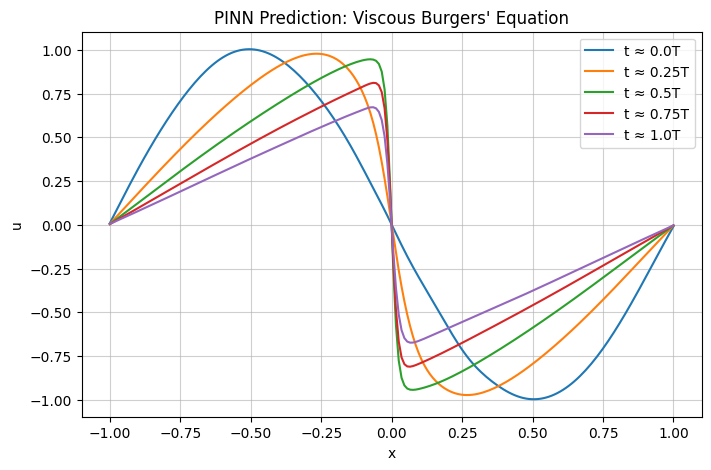

In [ ]:
# plotting the PINN results

x_eval = torch.linspace(-1.0, 1.0, 200).view(-1, 1)
t_steps = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(8, 5))

pinn_model.eval()
with torch.no_grad():
  for t_val in t_steps:
      t_eval = torch.full_like(x_eval, t_val)
      s_eval = torch.cat([x_eval, t_eval], dim=1)

      u_pred = pinn_model(s_eval)

      x_plot = x_eval.numpy()
      u_plot = u_pred.numpy()

      plt.plot(x_plot, u_plot, label=f"t ≈ {t_val}T")

plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("u")
plt.title("PINN Prediction: Viscous Burgers' Equation")
plt.grid(True, alpha=0.6)
plt.show()

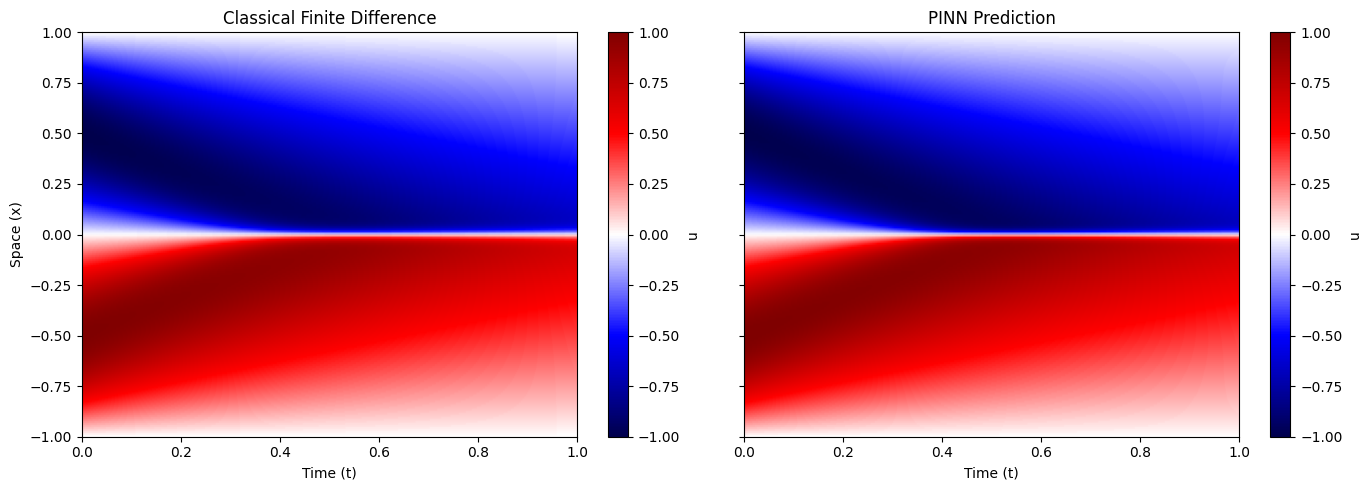

In [ ]:
# displaying relevant heatmaps

t_grid = np.linspace(0.0, 1.0, nt + 1)
x_grid = np.linspace(-1.0, 1.0, nx)

T_mesh, X_mesh = np.meshgrid(t_grid, x_grid)

x_flat = torch.tensor(X_mesh.flatten(), dtype=torch.float32).view(-1, 1)
t_flat = torch.tensor(T_mesh.flatten(), dtype=torch.float32).view(-1, 1)
s_eval = torch.cat([x_flat, t_flat], dim=1)

pinn_model.eval()
with torch.no_grad():
    u_pred_flat = pinn_model(s_eval).numpy()

u_pred_grid = u_pred_flat.reshape(X_mesh.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_args = {
    'extent': [0, 1.0, -1.0, 1.0],
    'origin': 'lower',
    'aspect': 'auto',
    'cmap': 'seismic',
    'vmin': -1.0,
    'vmax': 1.0
}

im1 = axes[0].imshow(u, **plot_args)
axes[0].set_title("Classical Finite Difference")
axes[0].set_xlabel("Time (t)")
axes[0].set_ylabel("Space (x)")
fig.colorbar(im1, ax=axes[0], label="u")

im2 = axes[1].imshow(u_pred_grid, **plot_args)
axes[1].set_title("PINN Prediction")
axes[1].set_xlabel("Time (t)")
fig.colorbar(im2, ax=axes[1], label="u")

plt.tight_layout()
plt.show()

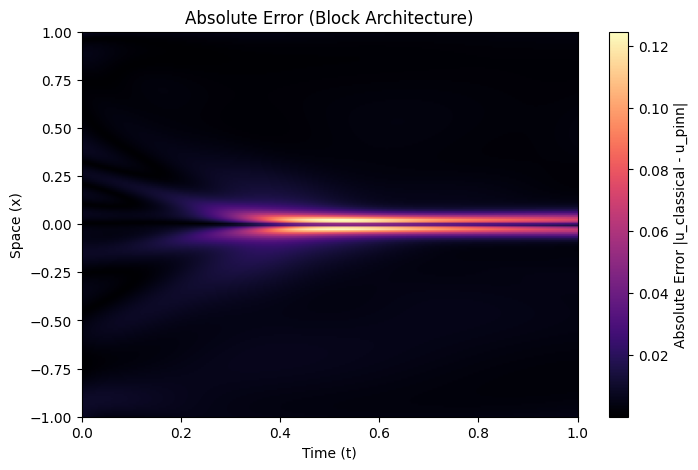

In [ ]:
# plotting absolute error

error_grid = np.abs(u_pred_grid - u)

plt.figure(figsize=(8, 5))
im_err = plt.imshow(error_grid,
                    extent=[0, 1.0, -1.0, 1.0],
                    origin='lower',
                    aspect='auto',
                    cmap='magma')
plt.colorbar(im_err, label="Absolute Error |u_classical - u_pinn|")
plt.title("Absolute Error (Block Architecture)")
plt.xlabel("Time (t)")
plt.ylabel("Space (x)")
plt.show()

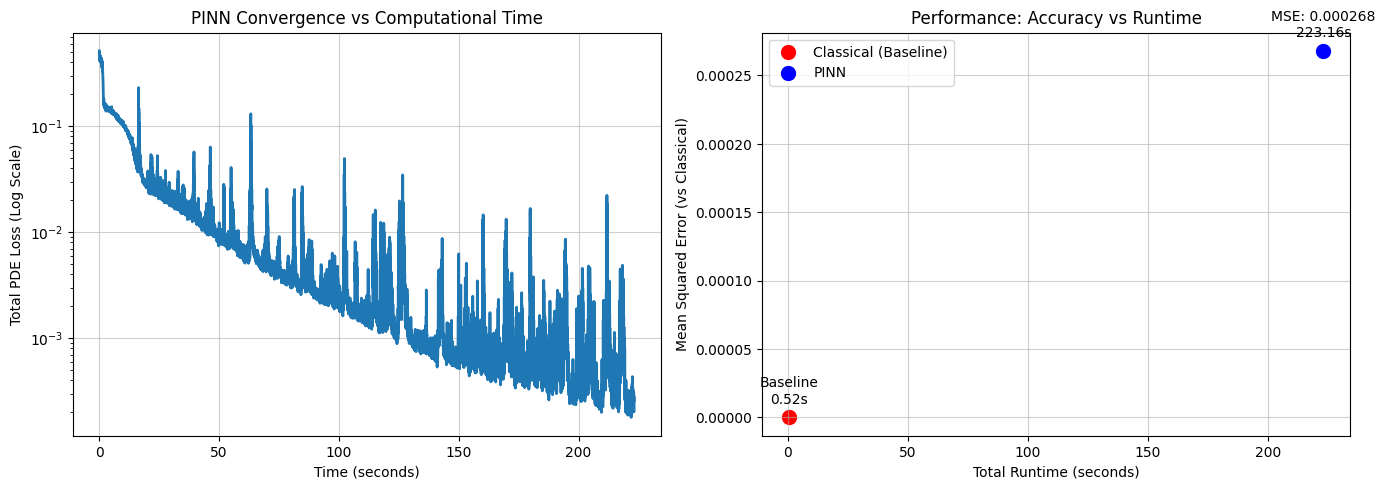

In [ ]:
# convergence and performance plots

final_mse = np.mean((u - u_pred_grid)**2)

classical_runtime = elapsed_time_classical
pinn_runtime = elapsed_time_pinn

time_per_epoch = pinn_runtime / epochs
time_axis = np.arange(epochs) * time_per_epoch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_axis, loss_history, linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title("PINN Convergence vs Computational Time")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Total PDE Loss (Log Scale)")
axes[0].grid(True, alpha=0.6)

axes[1].scatter(classical_runtime, 0, color='red', s=100, label='Classical (Baseline)')
axes[1].scatter(pinn_runtime, final_mse, color='blue', s=100, label='PINN')

axes[1].annotate(f'Baseline\n{classical_runtime:.2f}s', (classical_runtime, 0),
                 xytext=(0, 10), textcoords='offset points', ha='center')
axes[1].annotate(f'MSE: {final_mse:.6f}\n{pinn_runtime:.2f}s', (pinn_runtime, final_mse),
                 xytext=(0, 10), textcoords='offset points', ha='center')

axes[1].set_title("Performance: Accuracy vs Runtime")
axes[1].set_xlabel("Total Runtime (seconds)")
axes[1].set_ylabel("Mean Squared Error (vs Classical)")
axes[1].legend()
axes[1].grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

# Part 3: Ensemble PINN Training

In [ ]:
# ensemble PINN method

num_runs = 100
epochs = 10000

# lists to store the data for our comparison plots later
all_loss_histories = []
final_losses = []
run_times = []

# variables to track the absolute best model
lowest_loss = float('inf')
best_model_state = None

print(f"Starting {num_runs} independent PINN training runs...\n")

# looping the PINN training
for run in range(num_runs):
    print(f"--- Run {run + 1} / {num_runs} ---")
    start_time = time.time()

    # reinitializing model and optimizer so it starts fresh
    pinn_model = PDE_Net()
    optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.0015)

    loss_history = []

    # loss calculation and optimization step
    for epoch in range(epochs):
        optimizer.zero_grad()

        x_domain = L * torch.rand((1000, 1)) + x_min
        t_domain = T * torch.rand((1000, 1)) + t_min
        s_domain = torch.cat([x_domain, t_domain], dim=1)

        residual = compute_burgers_residual(pinn_model, s_domain, nu)
        loss_pde = torch.mean(residual**2)

        x_ic = L * torch.rand((200, 1)) + x_min
        t_ic = torch.zeros((200, 1))
        s_ic = torch.cat([x_ic, t_ic], dim=1)
        loss_ic = torch.mean((pinn_model(s_ic) - (-torch.sin(torch.pi * x_ic)))**2)

        t_bc = T * torch.rand((200, 1)) + t_min
        x_left = torch.full((200, 1), x_min)
        x_right = torch.full((200, 1), x_max)

        loss_bc_left = torch.mean(pinn_model(torch.cat([x_left, t_bc], dim=1))**2)
        loss_bc_right = torch.mean(pinn_model(torch.cat([x_right, t_bc], dim=1))**2)

        loss_total = loss_pde + loss_ic + loss_bc_left + loss_bc_right
        loss_total.backward()
        optimizer.step()

        loss_history.append(loss_total.item())

    # end of single run
    run_time = time.time() - start_time
    final_loss = loss_history[-1]

    all_loss_histories.append(loss_history)
    final_losses.append(final_loss)
    run_times.append(run_time)

    print(f"Completed in {run_time:.2f}s | Final Total Loss: {final_loss:.6f}\n")

    # check if this is the best model so far
    if final_loss < lowest_loss:
        lowest_loss = final_loss
        # deepcopy ensures we save the exact weights right now
        # before the next loop overwrites the model memory
        best_model_state = copy.deepcopy(pinn_model.state_dict())

# ensemble complete
print(f"Ensemble complete! Lowest loss achieved: {lowest_loss:.6f}")

# load the best weights into a final model for plotting/inference
best_pinn = PDE_Net()
best_pinn.load_state_dict(best_model_state)
best_pinn.eval()

Starting 100 independent PINN training runs...

--- Run 1 / 100 ---
Completed in 152.07s | Final Total Loss: 0.000953

--- Run 2 / 100 ---
Completed in 143.47s | Final Total Loss: 0.000946

--- Run 3 / 100 ---
Completed in 143.90s | Final Total Loss: 0.001900

--- Run 4 / 100 ---
Completed in 145.94s | Final Total Loss: 0.000723

--- Run 5 / 100 ---
Completed in 147.26s | Final Total Loss: 0.000388

--- Run 6 / 100 ---
Completed in 145.63s | Final Total Loss: 0.001619

--- Run 7 / 100 ---
Completed in 146.24s | Final Total Loss: 0.000394

--- Run 8 / 100 ---
Completed in 144.67s | Final Total Loss: 0.000354

--- Run 9 / 100 ---
Completed in 142.58s | Final Total Loss: 0.000735

--- Run 10 / 100 ---
Completed in 142.50s | Final Total Loss: 0.000655

--- Run 11 / 100 ---
Completed in 144.40s | Final Total Loss: 0.000871

--- Run 12 / 100 ---
Completed in 143.80s | Final Total Loss: 0.000162

--- Run 13 / 100 ---
Completed in 144.28s | Final Total Loss: 0.000294

--- Run 14 / 100 ---
Comp

PDE_Net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=35, bias=True)
    (1): Tanh()
    (2): Linear(in_features=35, out_features=35, bias=True)
    (3): Tanh()
    (4): Linear(in_features=35, out_features=35, bias=True)
    (5): Tanh()
    (6): Linear(in_features=35, out_features=35, bias=True)
    (7): Tanh()
    (8): Linear(in_features=35, out_features=1, bias=True)
  )
)

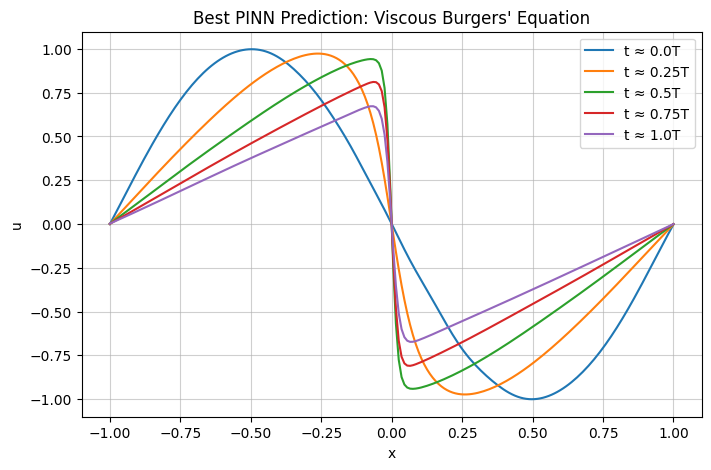

In [ ]:
# plotting the best PINN results

x_eval = torch.linspace(-1.0, 1.0, 200).view(-1, 1)
t_steps = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(8, 5))

best_pinn.eval()
with torch.no_grad():
  for t_val in t_steps:
      t_eval = torch.full_like(x_eval, t_val)
      s_eval = torch.cat([x_eval, t_eval], dim=1)

      u_pred = best_pinn(s_eval)

      x_plot = x_eval.numpy()
      u_plot = u_pred.numpy()

      plt.plot(x_plot, u_plot, label=f"t ≈ {t_val}T")

plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Best PINN Prediction: Viscous Burgers' Equation")
plt.grid(True, alpha=0.6)
plt.show()

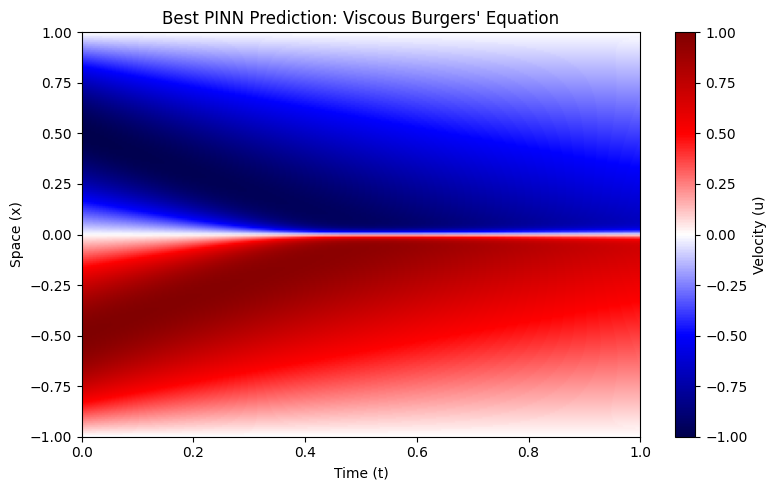

In [ ]:
# displaying heatmap

t_grid = np.linspace(0.0, 1.0, nt + 1)
x_grid = np.linspace(-1.0, 1.0, nx)
T_mesh, X_mesh = np.meshgrid(t_grid, x_grid)

x_flat = torch.tensor(X_mesh.flatten(), dtype=torch.float32).view(-1, 1)
t_flat = torch.tensor(T_mesh.flatten(), dtype=torch.float32).view(-1, 1)
s_eval = torch.cat([x_flat, t_flat], dim=1)

best_pinn.eval()
with torch.no_grad():
    u_best_pred_flat = best_pinn(s_eval).numpy()

u_best_pred_grid = u_best_pred_flat.reshape(X_mesh.shape)

plt.figure(figsize=(8, 5))

im = plt.imshow(u_best_pred_grid, extent=[0, 1.0, -1.0, 1.0],
                origin='lower', aspect='auto', cmap='seismic',
                vmin=-1.0, vmax=1.0)

plt.colorbar(im, label="Velocity (u)")
plt.title("Best PINN Prediction: Viscous Burgers' Equation")
plt.xlabel("Time (t)")
plt.ylabel("Space (x)")

plt.grid(False)
plt.tight_layout()
plt.show()

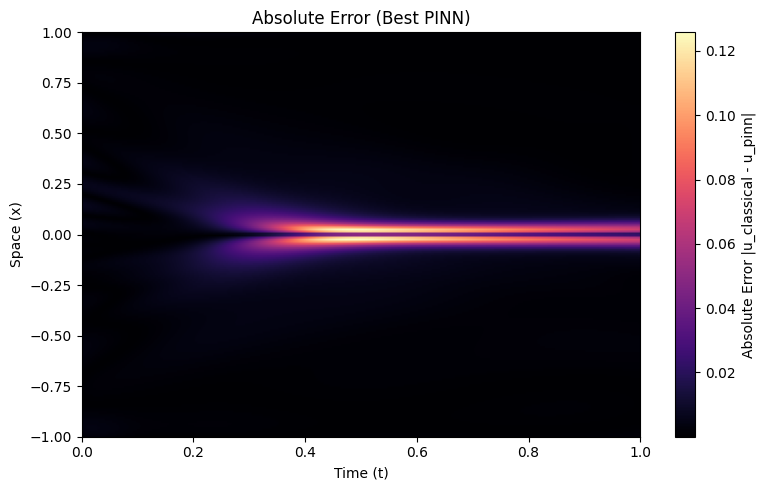

In [ ]:
# plotting absolute error

error_grid = np.abs(u - u_best_pred_grid)

plt.figure(figsize=(8, 5))

im_err = plt.imshow(error_grid, extent=[0, 1.0, -1.0, 1.0],
                    origin='lower', aspect='auto', cmap='magma')

plt.colorbar(im_err, label="Absolute Error |u_classical - u_pinn|")
plt.title("Absolute Error (Best PINN)")
plt.xlabel("Time (t)")
plt.ylabel("Space (x)")
plt.grid(False)

plt.tight_layout()
plt.show()

# Part 4: Statistical Analysis

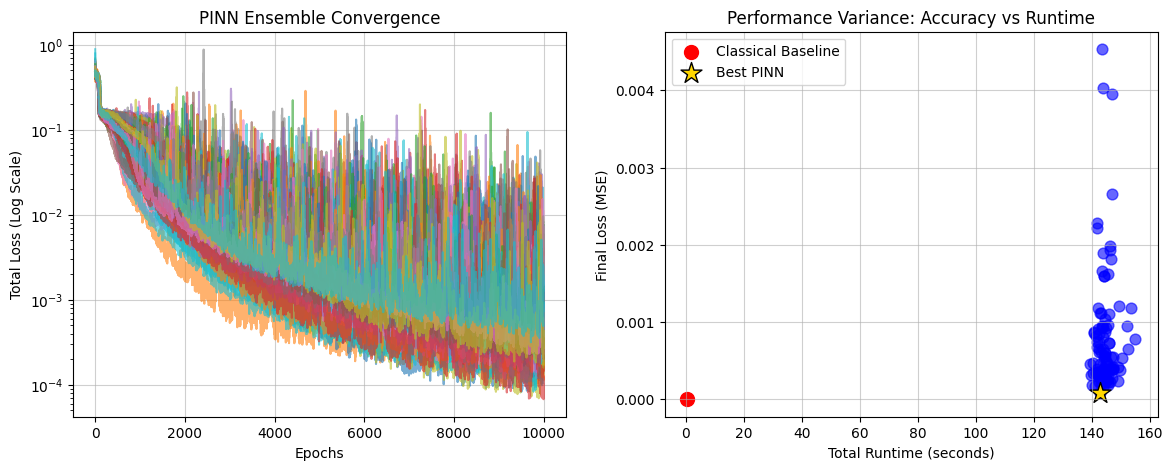

In [ ]:
# convergence and performance plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, history in enumerate(all_loss_histories):
    axes[0].plot(range(epochs), history, alpha=0.6, label=f'Run {i+1}')

axes[0].set_yscale('log')
axes[0].set_title("PINN Ensemble Convergence")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Total Loss (Log Scale)")
axes[0].grid(True, alpha=0.6)

classical_runtime = elapsed_time_classical
final_mse_classical = 0.0

axes[1].scatter(classical_runtime, final_mse_classical, color='red', s=100, label='Classical Baseline')

for rt, final_loss in zip(run_times, final_losses):
    axes[1].scatter(rt, final_loss, color='blue', s=60, alpha=0.6)

best_idx = final_losses.index(lowest_loss)
best_runtime = run_times[best_idx]

axes[1].scatter(best_runtime, lowest_loss, color='gold', marker='*', s=250, edgecolor='black', label='Best PINN')

axes[1].set_title("Performance Variance: Accuracy vs Runtime")
axes[1].set_xlabel("Total Runtime (seconds)")
axes[1].set_ylabel("Final Loss (MSE)")
axes[1].legend()
axes[1].grid(True, alpha=0.6)

Pearson Correlation Coefficient (r): 0.0628
P-value: 0.5346



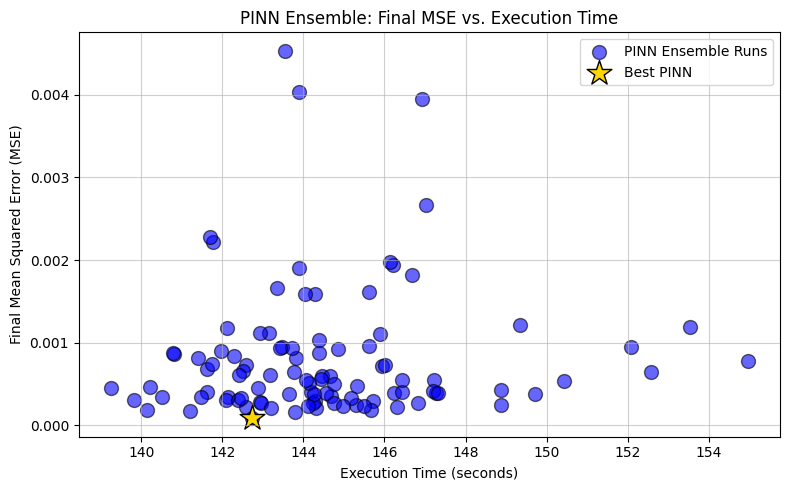

In [ ]:
# PINN performance scatterplot

correlation, p_value = pearsonr(run_times, final_losses)

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value:.4f}\n")

plt.figure(figsize=(8, 5))

plt.scatter(run_times, final_losses, color='blue', s=100, alpha=0.6, edgecolor='black', label='PINN Ensemble Runs')

best_idx = final_losses.index(min(final_losses))
best_runtime = run_times[best_idx]
best_loss = final_losses[best_idx]

plt.scatter(best_runtime, best_loss, color='gold', marker='*', s=350, edgecolor='black', label='Best PINN')

plt.title("PINN Ensemble: Final MSE vs. Execution Time")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Final Mean Squared Error (MSE)")
plt.grid(True, alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Gamma Fit Parameters:
Shape (α): 4.06
Location: 138.7471
Scale: 1.4261

Log-Normal Fit Parameters:
Shape (σ): 0.30
Location: 135.5012
Scale: 8.6252



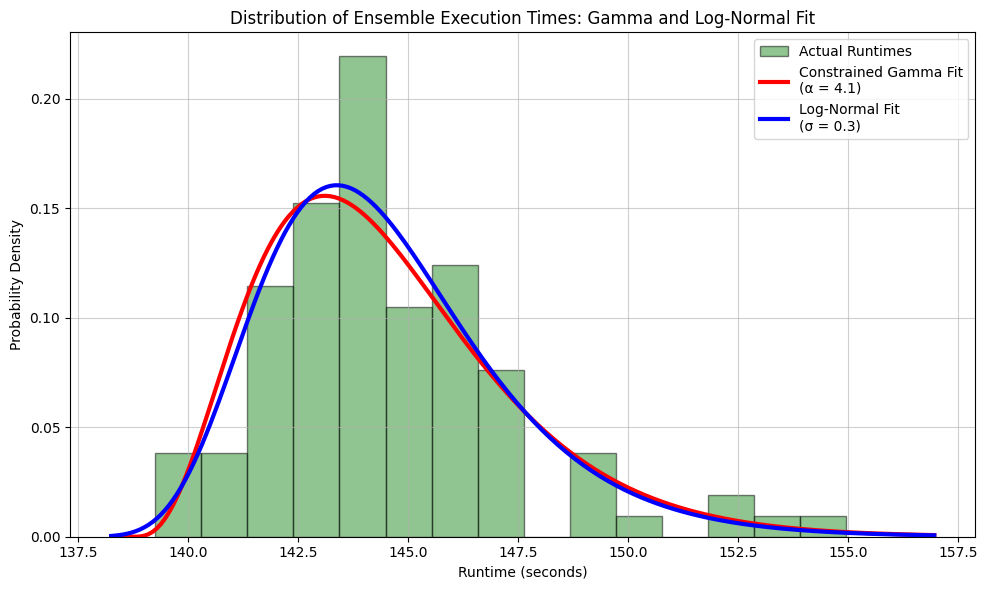

In [ ]:
# histogram of the runtime and gamma and log-normal fit

plt.figure(figsize=(10, 6))

plt.hist(run_times, bins=15, density=True, alpha=0.6, color='forestgreen', edgecolor='black', label='Actual Runtimes')

min_time = min(run_times)
shape_g, loc_g, scale_g = gamma.fit(run_times, floc=min_time - 0.5)

print(f"Gamma Fit Parameters:")
print(f"Shape (α): {shape_g:.2f}")
print(f"Location: {loc_g:.4f}")
print(f"Scale: {scale_g:.4f}\n")

x_vals = np.linspace(min_time - 1, max(run_times) + 2, 200)
pdf_gamma = gamma.pdf(x_vals, shape_g, loc=loc_g, scale=scale_g)

plt.plot(x_vals, pdf_gamma, 'r-', lw=3, label=f'Constrained Gamma Fit\n(α = {shape_g:.1f})')

shape_ln, loc_ln, scale_ln = lognorm.fit(run_times)
pdf_lognorm = lognorm.pdf(x_vals, shape_ln, loc=loc_ln, scale=scale_ln)

print(f"Log-Normal Fit Parameters:")
print(f"Shape (σ): {shape_ln:.2f}")
print(f"Location: {loc_ln:.4f}")
print(f"Scale: {scale_ln:.4f}\n")

plt.plot(x_vals, pdf_lognorm, 'b-', lw=3, label=f'Log-Normal Fit\n(σ = {shape_ln:.1f})')

plt.title("Distribution of Ensemble Execution Times: Gamma and Log-Normal Fit")
plt.xlabel("Runtime (seconds)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

Gamma Fit Parameters:
Shape (α): 1.29
Location: 0.0001
Scale: 0.0006

Log-Normal Fit Parameters:
Shape (σ): 0.86
Location: 0.0000
Scale: 0.0005



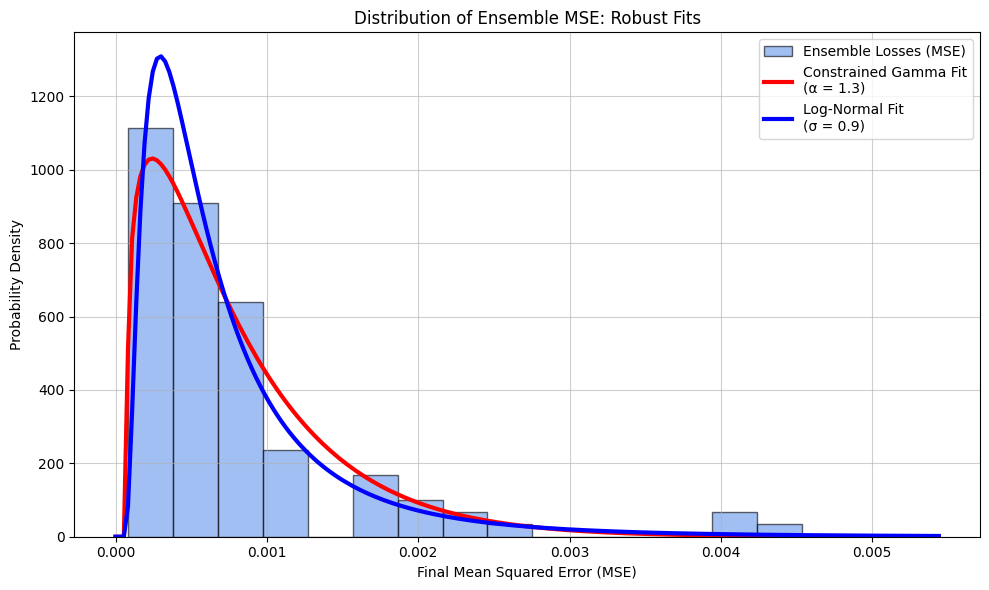

In [ ]:
# histogram of the MSE and gamma and log-normal fit

plt.figure(figsize=(10, 6))

plt.hist(final_losses, bins=15, density=True, alpha=0.6, color='cornflowerblue', edgecolor='black', label='Ensemble Losses (MSE)')

min_mse = min(final_losses)
buffer = min_mse * 0.1  # 10% buffer below the minimum to avoid inaccurate PDF
shape_g, loc_g, scale_g = gamma.fit(final_losses, floc=min_mse - buffer)

print(f"Gamma Fit Parameters:")
print(f"Shape (α): {shape_g:.2f}")
print(f"Location: {loc_g:.4f}")
print(f"Scale: {scale_g:.4f}\n")

x_vals = np.linspace(0, max(final_losses) * 1.2, 200)
pdf_gamma = gamma.pdf(x_vals, shape_g, loc=loc_g, scale=scale_g)

plt.plot(x_vals, pdf_gamma, 'r-', lw=3, label=f'Constrained Gamma Fit\n(α = {shape_g:.1f})')

shape_ln, loc_ln, scale_ln = lognorm.fit(final_losses)
pdf_lognorm = lognorm.pdf(x_vals, shape_ln, loc=loc_ln, scale=scale_ln)

print(f"Log-Normal Fit Parameters:")
print(f"Shape (σ): {shape_ln:.2f}")
print(f"Location: {loc_ln:.4f}")
print(f"Scale: {scale_ln:.4f}\n")

plt.plot(x_vals, pdf_lognorm, 'b-', lw=3, label=f'Log-Normal Fit\n(σ = {shape_ln:.1f})')

plt.title("Distribution of Ensemble MSE: Robust Fits")
plt.xlabel("Final Mean Squared Error (MSE)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()